In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=4,random_state=42)

In [4]:
df = pd.DataFrame(X, columns=['Feature1','Feature2'])

In [5]:
df

,Feature1,Feature2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868
...,...,...
495,-1.282205,-3.181575
496,-2.817604,10.378894
497,3.296740,8.649256
498,-8.970519,-2.684073


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [7]:
inertia = []
K_range = range(1,11)

In [8]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [9]:
inertia

[1000.0,
 528.8064432605652,
 294.4377068678189,
 250.45524696534463,
 216.8811065698262,
 185.27440675195916,
 156.70879996290458,
 135.62603453115258,
 129.1039634823982,
 119.94101297105]

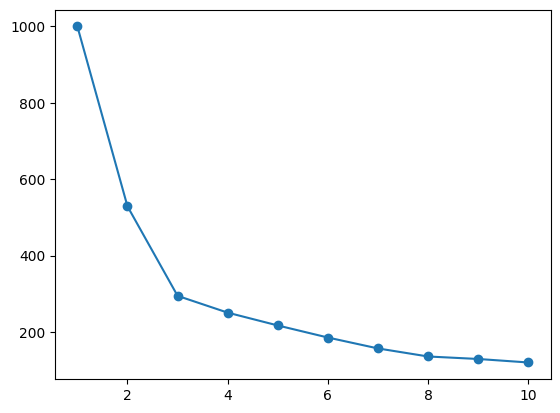

In [10]:
plt.plot(K_range,inertia, marker='o')

In [64]:
kmeans_final = KMeans(n_clusters=4, random_state=42)

In [65]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [66]:
df['clusters'] = cluster_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

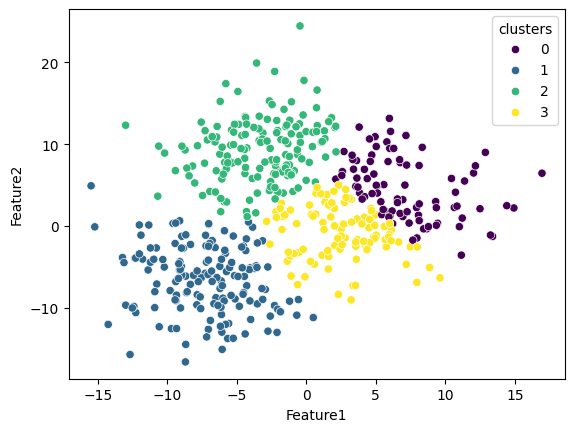

In [67]:
sns.scatterplot(x=df['Feature1'],
                y=df['Feature2'],
                hue=df['clusters'],
                palette='viridis')

In [68]:
from sklearn.datasets import make_moons

In [69]:
X,y_true = make_moons(n_samples=500,noise=0.05,random_state=42)

In [70]:
from sklearn.cluster import KMeans,DBSCAN

In [71]:
df = pd.DataFrame(X,columns=['Feature1','Feature2'])

In [72]:
df

,Feature1,Feature2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
...,...,...
495,0.239754,0.985462
496,0.072145,0.184834
497,0.590273,-0.365577
498,1.619465,-0.283658


In [73]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [74]:
kmeans = KMeans(n_clusters=2,random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [75]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

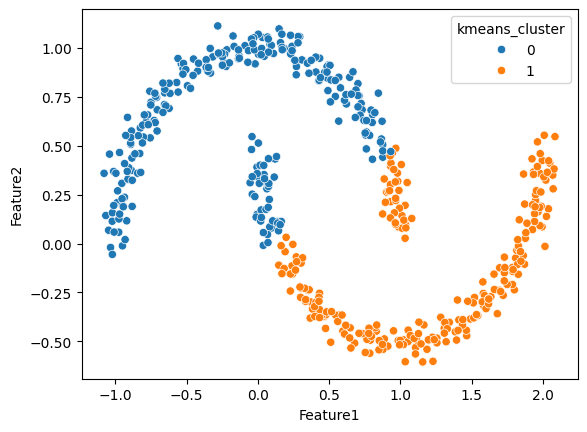

In [76]:
sns.scatterplot(x=df['Feature1'],
                y=df['Feature2'],
                hue=df['kmeans_cluster'],
                palette='tab10')

In [77]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [78]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

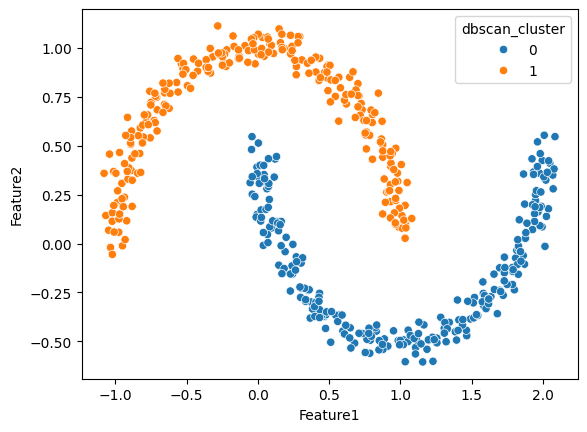

In [79]:
sns.scatterplot(x=df['Feature1'],
                y=df['Feature2'],
                hue=df['dbscan_cluster'],
                palette='tab10')